<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">Imports</span>
</div>

In [1]:
!pip install numpy pandas matplotlib seaborn wordcloud plotly nltk scikit-learn xgboost


In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NLP Libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier



plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
color_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
print(" All libraries imported successfully!")

 All libraries imported successfully!


In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;"> Load the dataset
</span>
</div>

In [3]:
df = pd.read_csv('/kaggle/input/datasets/abeingijo/aidetect/AI_Human.csv')

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(df.head())
print(f"\nLast 5 rows:")
display(df.tail())
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nBasic Statistics for 'generated' column:")
print(df['generated'].describe())

DATASET INFORMATION
Dataset Shape: (487235, 2)

Columns: ['text', 'generated']

First 5 rows:


,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0



Last 5 rows:


,text,generated
487230,Tie Face on Mars is really just a big misunder...,0.0
487231,The whole purpose of democracy is to create a ...,0.0
487232,I firmly believe that governments worldwide sh...,1.0
487233,I DFN't agree with this decision because a LFT...,0.0
487234,"Richard Non, Jimmy Carter, and Bob Dole and ot...",0.0



Data Types:
text          object
generated    float64
dtype: object

Missing Values:
text         0
generated    0
dtype: int64

Basic Statistics for 'generated' column:
count    487235.000000
mean          0.372383
std           0.483440
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: generated, dtype: float64


<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">Preparing and understanding the data</span>
</div>

In [4]:
print("=" * 60)
print("ANALYZING 'generated' COLUMN")
print("=" * 60)

unique_values = df['generated'].unique()
print(f"Unique values in 'generated': {unique_values}")
print(f"Data type of 'generated': {df['generated'].dtype}")

print(f"\nValue counts:")
print(df['generated'].value_counts())
print(f"\nValue counts (normalized):")
print(df['generated'].value_counts(normalize=True))

df['label'] = df['generated'].apply(lambda x: 'AI' if x == 1.0 else 'Human')
print(f"\nNew 'label' column created from 'generated'")
print(f"Label distribution:\n{df['label'].value_counts()}")
print(f"\nLabel distribution (%):\n{df['label'].value_counts(normalize=True) * 100}")

print(f"\nChecking for inconsistencies:")
print(f"Number of rows where generated is 0.0: {(df['generated'] == 0.0).sum()}")
print(f"Number of rows where generated is 1.0: {(df['generated'] == 1.0).sum()}")
print(f"Total rows: {len(df)}")

ANALYZING 'generated' COLUMN
Unique values in 'generated': [0. 1.]
Data type of 'generated': float64

Value counts:
generated
0.0    305797
1.0    181438
Name: count, dtype: int64

Value counts (normalized):
generated
0.0    0.627617
1.0    0.372383
Name: proportion, dtype: float64

New 'label' column created from 'generated'
Label distribution:
label
Human    305797
AI       181438
Name: count, dtype: int64

Label distribution (%):
label
Human    62.761706
AI       37.238294
Name: proportion, dtype: float64

Checking for inconsistencies:
Number of rows where generated is 0.0: 305797
Number of rows where generated is 1.0: 181438
Total rows: 487235


<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">Text Preprocessing</span>
</div>

In [7]:
# Initialize NLP tools
print(" Downloading NLTK resources...")
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-eng', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Comprehensive text preprocessing function
    """
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    text = re.sub(r'<.*?>', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = word_tokenize(text)
    
    tokens = [lemmatizer.lemmatize(word) for word in tokens 
              if word not in stop_words and len(word) > 2]
    
    return ' '.join(tokens)

print(" Starting text preprocessing...")
print(f"Total texts to process: {len(df)}")

batch_size = 50000
cleaned_texts = []

for i in range(0, len(df), batch_size):
    batch = df['text'].iloc[i:i+batch_size]
    cleaned_batch = batch.apply(preprocess_text)
    cleaned_texts.extend(cleaned_batch)
    
    progress = min(i + batch_size, len(df))
    print(f"  Processed {progress}/{len(df)} texts ({progress/len(df)*100:.1f}%)")

df['cleaned_text'] = cleaned_texts

original_len = df['text'].str.len().mean()
cleaned_len = df['cleaned_text'].str.len().mean()
original_words = df['text'].apply(lambda x: len(str(x).split())).mean()
cleaned_words = df['cleaned_text'].apply(lambda x: len(str(x).split())).mean()

print("\n" + "=" * 60)
print("PREPROCESSING RESULTS")
print("=" * 60)
print(f"Average text length:")
print(f"  Original: {original_len:.0f} characters")
print(f"  Cleaned: {cleaned_len:.0f} characters")
print(f"  Reduction: {((original_len - cleaned_len)/original_len)*100:.1f}%")

print(f"\nAverage word count:")
print(f"  Original: {original_words:.0f} words")
print(f"  Cleaned: {cleaned_words:.0f} words")
print(f"  Reduction: {((original_words - cleaned_words)/original_words)*100:.1f}%")

# Show sample of processed text
print("\n" + "=" * 80)
print("SAMPLE OF ORIGINAL VS CLEANED TEXT")
print("=" * 80)

sample_indices = np.random.choice(len(df), 3, replace=False)
for idx in sample_indices:
    print(f"\n Sample #{list(sample_indices).index(idx) + 1} ({df['label'].iloc[idx]}):")
    print(f"\nOriginal (first 300 chars):")
    print(f"{df['text'].iloc[idx][:300]}...")
    print(f"\nCleaned:")
    print(f"{df['cleaned_text'].iloc[idx][:300]}..." if len(df['cleaned_text'].iloc[idx]) > 300 
          else df['cleaned_text'].iloc[idx])
    print("-" * 80)

 Starting text preprocessing...
Total texts to process: 487235


[nltk_data] Error loading omw-eng: Package 'omw-eng' not found in
[nltk_data]     index


  Processed 50000/487235 texts (10.3%)
  Processed 100000/487235 texts (20.5%)
  Processed 150000/487235 texts (30.8%)
  Processed 200000/487235 texts (41.0%)
  Processed 250000/487235 texts (51.3%)
  Processed 300000/487235 texts (61.6%)
  Processed 350000/487235 texts (71.8%)
  Processed 400000/487235 texts (82.1%)
  Processed 450000/487235 texts (92.4%)
  Processed 487235/487235 texts (100.0%)

PREPROCESSING RESULTS
Average text length:
  Original: 2270 characters
  Cleaned: 1427 characters
  Reduction: 37.1%

Average word count:
  Original: 393 words
  Cleaned: 201 words
  Reduction: 48.8%

SAMPLE OF ORIGINAL VS CLEANED TEXT

 Sample #1 (Human):

Original (first 300 chars):
The thought of having driverless cars being introduced in the near future is for one, scary and exciting. There are two ways that you can come about the driverless cars, you can enjoy and agree with the idea, or you can disagree.

Google has been working on this project since 2009, they have built c...

Cleaned:

<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">Feature Engineering</span>
</div>

In [8]:
print(" Creating TF-IDF features...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,  
    ngram_range=(1, 3),  
    min_df=10,           
    max_df=0.8,          
    stop_words='english',
    sublinear_tf=True,   
    smooth_idf=True      
)

X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_text'])
print(f" TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f" Number of Features: {X_tfidf.shape[1]}")



 Creating TF-IDF features...
 TF-IDF Matrix Shape: (487235, 10000)
 Number of Features: 10000


<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">Train-Test Split</span>
</div>

DATA PREPARATION FOR MODELING
Label mapping: {'AI': np.int64(0), 'Human': np.int64(1)}
Original labels: ['AI' 'Human']

 Dataset Split Information:
----------------------------------------
Total samples: 487235
Training set: 341064 samples (70.0%)
Validation set: 48724 samples (10.0%)
Testing set: 97447 samples (20.0%)
Number of features: 10000

 Class Distribution:
----------------------------------------


,Human,AI,Total,Human %,AI %
Train,127006,214058,341064,37.2,62.8
Validation,18144,30580,48724,37.2,62.8
Test,36288,61159,97447,37.2,62.8


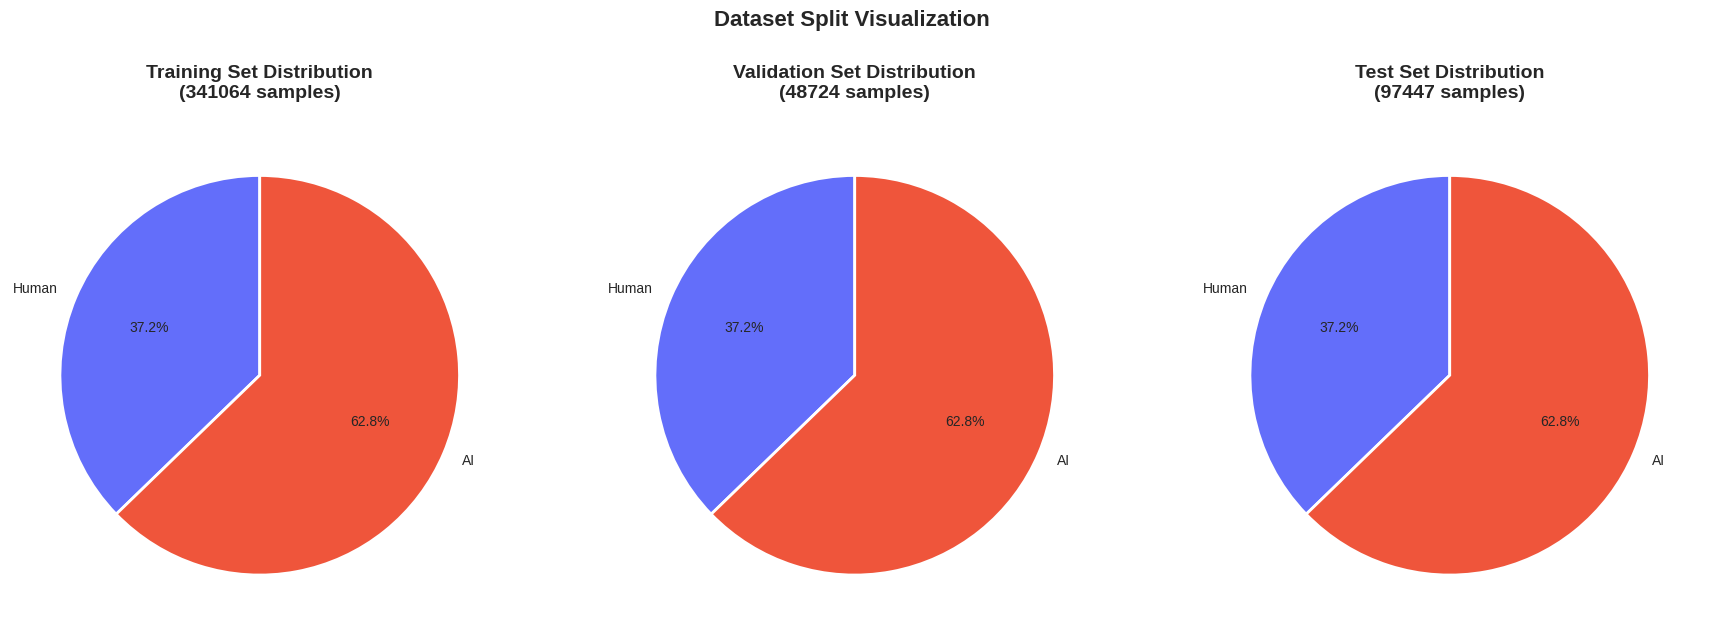

In [9]:
# Prepare data
X = X_tfidf
y = df['label']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("=" * 60)
print("DATA PREPARATION FOR MODELING")
print("=" * 60)
print(f"Label mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"Original labels: {label_encoder.classes_}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, stratify=y_train
)

print("\n Dataset Split Information:")
print("-" * 40)
print(f"Total samples: {X.shape[0]}")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Number of features: {X_train.shape[1]}")

print("\n Class Distribution:")
print("-" * 40)
train_counts = pd.Series(y_train).value_counts().sort_index()
val_counts = pd.Series(y_val).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

dist_df = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
    'Test': test_counts
}).T
dist_df.columns = ['Human', 'AI']
dist_df['Total'] = dist_df.sum(axis=1)
dist_df['Human %'] = (dist_df['Human'] / dist_df['Total'] * 100).round(1)
dist_df['AI %'] = (dist_df['AI'] / dist_df['Total'] * 100).round(1)

display(dist_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (name, counts, ax) in enumerate(zip(['Training', 'Validation', 'Test'],
                                             [train_counts, val_counts, test_counts],
                                             axes)):
    ax.pie(counts.values, labels=['Human', 'AI'], 
           colors=color_palette[:2], autopct='%1.1f%%',
           startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
    ax.set_title(f'{name} Set Distribution\n({counts.sum()} samples)', 
                fontsize=14, fontweight='bold', pad=20)

plt.suptitle('Dataset Split Visualization', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">Create Custom Test Examples</span>
</div>

In [10]:

custom_examples = [
    {
        "text": "I woke up late this morning and rushed to get ready for work. The traffic was terrible, as usual. I stopped for coffee but the line was too long, so I had to skip it. My day just didn't start well at all.",
        "expected": "Human",
        "description": "Personal narrative with emotions and daily routine"
    },
    {
        "text": "So I was thinking about what to cook for dinner tonight, maybe some pasta with garlic bread. But then I remembered we're out of garlic. Ugh, guess I'll have to improvise or just order pizza instead.",
        "expected": "Human",
        "description": "Casual, conversational style with hesitation"
    },
    {
        "text": "The movie last night was okay, but the ending felt rushed. I mean, they spent two hours building up the characters and then wrapped everything up in five minutes. I expected more from that director.",
        "expected": "Human",
        "description": "Subjective opinion with criticism"
    },
    
    {
        "text": "The proliferation of artificial intelligence technologies has precipitated a paradigm shift in computational methodologies, thereby engendering novel approaches to problem-solving in diverse domains including healthcare, finance, and autonomous systems.",
        "expected": "AI",
        "description": "Formal, academic style with complex vocabulary"
    },
    {
        "text": "To optimize operational efficiency, organizations must implement robust data governance frameworks that ensure data quality, security, and compliance with regulatory requirements while facilitating data-driven decision-making processes.",
        "expected": "AI",
        "description": "Corporate/business jargon, structured"
    },
    {
        "text": "Climate change represents a significant global challenge that necessitates immediate action through international cooperation, policy interventions, and technological innovation to mitigate its adverse impacts on ecosystems and human societies.",
        "expected": "AI",
        "description": "Formal, structured, topic-focused"
    },
    
    {
        "text": "Once upon a time in a quaint little village nestled between rolling hills and lush forests, there lived an elderly artisan renowned for crafting exquisite wooden sculptures that seemed to capture the very essence of nature's beauty.",
        "expected": "Mixed",
        "description": "Creative writing, could be either"
    },
    {
        "text": "Hey there! Just wanted to check in and see how you've been doing lately. It's been ages since we last caught up! Work has been absolutely crazy - tons of deadlines and meetings back-to-back. Anyway, drop me a line when you get a chance!",
        "expected": "Human",
        "description": "Informal, personal communication"
    },
    {
        "text": "The quantum entanglement phenomenon, whereby pairs or groups of particles interact in such a manner that the quantum state of each particle cannot be described independently of the state of the others, remains a subject of extensive research in theoretical physics.",
        "expected": "AI",
        "description": "Scientific/technical explanation"
    },
  
    {
        "text": "Application for MSc in Data Science and Artificial Intelligence My interest in artificial intelligence developed during my undergraduate studies in Data Science and Artificial Intelligence at the University of Doha for Science and Technology. Through my coursework and projects, I became increasingly interested in how machine learning techniques can be applied to complex real-world problems. While theoretical learning provided a strong foundation, working on practical projects helped me understand the challenges involved in building reliable and scalable AI systems. These experiences motivated me to pursue graduate study in Data Science and Artificial Intelligence to deepen my knowledge and contribute to research-driven innovation in the field. One of the most formative experiences in my academic journey was my research internship at the Qatar Computing Research Institute (QCRI). During this internship, I worked on federated learning models for medical image classification, focusing on oral cancer detection using distributed deep learning approaches. Federated learning allows models to be trained collaboratively across multiple data sources without sharing sensitive data, which is particularly important in healthcare environments where privacy is critical. As part of this work, I helped design and implement a hybrid federated learning algorithm that integrates multiple optimization strategies to improve model performance and robustness across heterogeneous datasets. This experience strengthened my interest in machine learning research and exposed me to the process of designing, implementing, and evaluating advanced AI models.Alongside my research experience, I have also developed practical software and data engineering skills through various academic projects. I have worked on predictive machine learning pipelines using Python and Scikit-learn, where I applied feature engineering techniques and evaluation metrics to improve model performance. In addition, I developed backend systems using REST APIs and SQL databases to enable secure communication between application components. These experiences allowed me to gain a deeper understanding of how data science models interact with real software systems and how scalable solutions can be built from both the data and engineering perspectives. While my undergraduate studies have provided a strong technical foundation, I am eager to further explore advanced topics in artificial intelligence, including deep learning architectures, large-scale data systems, and trustworthy AI methods. I am particularly interested in research that combines machine learning with real-world applications such as healthcare, where AI systems can support experts in analyzing complex data and improving decision-making.Hamad Bin Khalifa University offers me an ideal environment for pursuing these interests due to its strong emphasis on research and innovation in artificial intelligence and data science. The opportunity to learn in a research-focused environment and collaborate with faculty working on impactful AI applications strongly aligns with my academic and professional goals. I look forward to contributing to the HBKU research community while continuing to develop my skills as a data scientist and AI researcher.",
        "expected": "AI",
        "description": "xyz"
    }
]

custom_df = pd.DataFrame(custom_examples)
print(f"Created {len(custom_df)} custom examples for testing")
print("\nExample Types Distribution:")
print(custom_df['expected'].value_counts())

Created 10 custom examples for testing

Example Types Distribution:
expected
AI       5
Human    4
Mixed    1
Name: count, dtype: int64


<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;"> Preprocess Custom Examples</span>
</div>

In [11]:

custom_df['cleaned_text'] = custom_df['text'].apply(preprocess_text)

print("\n Preprocessing Statistics:")
for i, row in custom_df.iterrows():
    original_len = len(row['text'])
    cleaned_len = len(row['cleaned_text'])
    reduction = ((original_len - cleaned_len) / original_len * 100) if original_len > 0 else 0
    
    print(f"\nExample {i+1} ({row['description'][:30]}...):")
    print(f"  Original: {original_len} chars")
    print(f"  Cleaned: {cleaned_len} chars")
    print(f"  Reduction: {reduction:.1f}%")

print("\n" + "=" * 80)
print("CLEANED TEXT EXAMPLES")
print("=" * 80)
for i in range(min(10, len(custom_df)+1)):
    print(f"\nExample {i+1} (Expected: {custom_df.iloc[i]['expected']}):")
    print(f"Original: {custom_df.iloc[i]['text'][:150]}...")
    print(f"Cleaned: {custom_df.iloc[i]['cleaned_text'][:150]}...")


 Preprocessing Statistics:

Example 1 (Personal narrative with emotio...):
  Original: 204 chars
  Cleaned: 107 chars
  Reduction: 47.5%

Example 2 (Casual, conversational style w...):
  Original: 198 chars
  Cleaned: 111 chars
  Reduction: 43.9%

Example 3 (Subjective opinion with critic...):
  Original: 198 chars
  Cleaned: 128 chars
  Reduction: 35.4%

Example 4 (Formal, academic style with co...):
  Original: 253 chars
  Cleaned: 215 chars
  Reduction: 15.0%

Example 5 (Corporate/business jargon, str...):
  Original: 236 chars
  Cleaned: 204 chars
  Reduction: 13.6%

Example 6 (Formal, structured, topic-focu...):
  Original: 244 chars
  Cleaned: 203 chars
  Reduction: 16.8%

Example 7 (Creative writing, could be eit...):
  Original: 232 chars
  Cleaned: 168 chars
  Reduction: 27.6%

Example 8 (Informal, personal communicati...):
  Original: 236 chars
  Cleaned: 130 chars
  Reduction: 44.9%

Example 9 (Scientific/technical explanati...):
  Original: 265 chars
  Cleaned: 189 chars
 

<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">TRAIN YOURS HEREE</span>
</div>

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

results = []

def evaluate_model(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test):
    print("\n" + "="*70)
    print(f"TRAINING: {model_name}")
    print("="*70)
    
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Validation predictions
    y_val_pred = model.predict(X_val)
    
    # Test predictions
    y_test_pred = model.predict(X_test)
    
    # Probabilities / scores
    if hasattr(model, "predict_proba"):
        y_val_prob = model.predict_proba(X_val)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_val_prob = None
        y_test_prob = None
    
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    if y_test_prob is not None:
        test_auc = roc_auc_score(y_test, y_test_prob)
    else:
        test_auc = None
    
    print(f"\nTraining Time: {train_time:.2f} sec")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Validation F1-score: {val_f1:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test F1-score: {test_f1:.4f}")
    if test_auc is not None:
        print(f"Test ROC-AUC: {test_auc:.4f}")
    
    print("\nClassification Report (Test Set):")
    print(classification_report(
        y_test, y_test_pred,
        target_names=label_encoder.classes_
    ))
    
    cm = confusion_matrix(y_test, y_test_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
    results.append({
        "Model": model_name,
        "Val Accuracy": val_acc,
        "Val F1": val_f1,
        "Test Accuracy": test_acc,
        "Test F1": test_f1,
        "Test AUC": test_auc,
        "Training Time (s)": train_time
    })
    
    return model


TRAINING: Multinomial Naive Bayes

Training Time: 0.25 sec
Validation Accuracy: 0.9632
Validation F1-score: 0.9708
Test Accuracy: 0.9637
Test F1-score: 0.9712
Test ROC-AUC: 0.9938

Classification Report (Test Set):
              precision    recall  f1-score   support

          AI       0.96      0.95      0.95     36288
       Human       0.97      0.97      0.97     61159

    accuracy                           0.96     97447
   macro avg       0.96      0.96      0.96     97447
weighted avg       0.96      0.96      0.96     97447



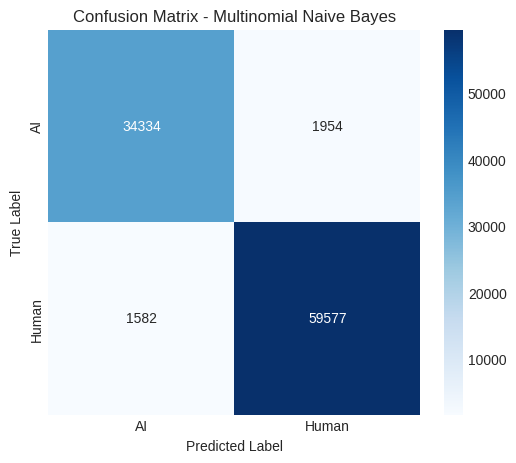

In [13]:
nb_model = MultinomialNB(alpha=1.0)

nb_model = evaluate_model(
    nb_model,
    "Multinomial Naive Bayes",
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)


TRAINING: XGBoost

Training Time: 12.60 sec
Validation Accuracy: 0.6913
Validation F1-score: 0.7695
Test Accuracy: 0.6920
Test F1-score: 0.7704
Test ROC-AUC: 0.6543

Classification Report (Test Set):
              precision    recall  f1-score   support

          AI       0.61      0.47      0.53     36288
       Human       0.72      0.82      0.77     61159

    accuracy                           0.69     97447
   macro avg       0.67      0.65      0.65     97447
weighted avg       0.68      0.69      0.68     97447



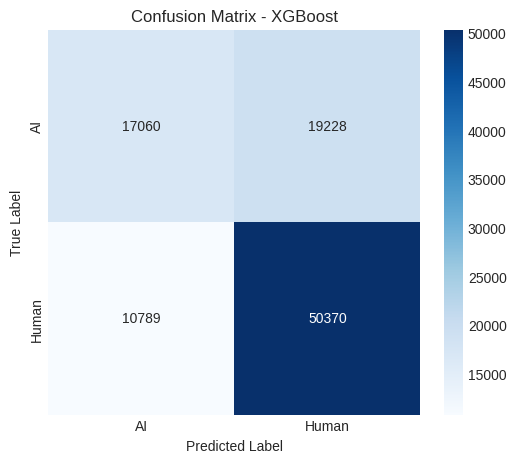

In [14]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    device='cuda'
)

xgb_model = evaluate_model(
    xgb_model,
    "XGBoost",
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">TEST YOURS HEREE on Custom Examples</span>
</div>

In [15]:
print(f"\nTesting {len(custom_df)} custom examples with Naive Bayes...")
print("-" * 60)

results = []
correct_count = 0

for idx, example in custom_df.iterrows():
    cleaned = preprocess_text(example['text'])
    features = tfidf_vectorizer.transform([cleaned])
    prediction = nb_model.predict(features)[0]
    label = label_encoder.inverse_transform([prediction])[0]

    if hasattr(nb_model, "predict_proba"):
        proba = nb_model.predict_proba(features)[0]
        human_prob = proba[0]
        ai_prob = proba[1] if len(proba) > 1 else 1 - human_prob
        confidence = proba[prediction]
    else:
        human_prob, ai_prob, confidence = 0.5, 0.5, 0.8

    correct = label == example['expected']
    if correct:
        correct_count += 1

    print(f"\nExample {idx+1}: {example['description']}")
    print(f"Text: {example['text'][:80]}...")
    print(f"Expected: {example['expected']}")
    print(f"Predicted: {label} (Confidence: {confidence:.1%})")
    print(f"Human Probability: {human_prob:.1%}, AI Probability: {ai_prob:.1%}")
    print(f"Result: {'✓' if correct else '✗'}")

print("\n" + "=" * 60)
print(f"Naive Bayes Accuracy: {correct_count}/{len(custom_df)} = {correct_count/len(custom_df):.1%}")


Testing 10 custom examples with Naive Bayes...
------------------------------------------------------------

Example 1: Personal narrative with emotions and daily routine
Text: I woke up late this morning and rushed to get ready for work. The traffic was te...
Expected: Human
Predicted: Human (Confidence: 94.5%)
Human Probability: 5.5%, AI Probability: 94.5%
Result: ✓

Example 2: Casual, conversational style with hesitation
Text: So I was thinking about what to cook for dinner tonight, maybe some pasta with g...
Expected: Human
Predicted: Human (Confidence: 68.2%)
Human Probability: 31.8%, AI Probability: 68.2%
Result: ✓

Example 3: Subjective opinion with criticism
Text: The movie last night was okay, but the ending felt rushed. I mean, they spent tw...
Expected: Human
Predicted: Human (Confidence: 60.7%)
Human Probability: 39.3%, AI Probability: 60.7%
Result: ✓

Example 4: Formal, academic style with complex vocabulary
Text: The proliferation of artificial intelligence technologies 

In [16]:
print(f"\nTesting {len(custom_df)} custom examples with XGB..")
print("-" * 60)

results = []
correct_count = 0

for idx, example in custom_df.iterrows():
    cleaned = preprocess_text(example['text'])
    features = tfidf_vectorizer.transform([cleaned])
    prediction = xgb_model.predict(features)[0]
    label = label_encoder.inverse_transform([prediction])[0]

    if hasattr(xgb_model, "predict_proba"):
        proba = xgb_model.predict_proba(features)[0]
        human_prob = proba[0]
        ai_prob = proba[1] if len(proba) > 1 else 1 - human_prob
        confidence = proba[prediction]
    else:
        human_prob, ai_prob, confidence = 0.5, 0.5, 0.8

    correct = label == example['expected']
    if correct:
        correct_count += 1

    print(f"\nExample {idx+1}: {example['description']}")
    print(f"Text: {example['text'][:80]}...")
    print(f"Expected: {example['expected']}")
    print(f"Predicted: {label} (Confidence: {confidence:.1%})")
    print(f"Human Probability: {human_prob:.1%}, AI Probability: {ai_prob:.1%}")
    print(f"Result: {'✓' if correct else '✗'}")

print("\n" + "=" * 60)
print(f"XGBoost Accuracy: {correct_count}/{len(custom_df)} = {correct_count/len(custom_df):.1%}")


Testing 10 custom examples with XGB..
------------------------------------------------------------

Example 1: Personal narrative with emotions and daily routine
Text: I woke up late this morning and rushed to get ready for work. The traffic was te...
Expected: Human
Predicted: Human (Confidence: 100.0%)
Human Probability: 0.0%, AI Probability: 100.0%
Result: ✓

Example 2: Casual, conversational style with hesitation
Text: So I was thinking about what to cook for dinner tonight, maybe some pasta with g...
Expected: Human
Predicted: Human (Confidence: 100.0%)
Human Probability: 0.0%, AI Probability: 100.0%
Result: ✓

Example 3: Subjective opinion with criticism
Text: The movie last night was okay, but the ending felt rushed. I mean, they spent tw...
Expected: Human
Predicted: Human (Confidence: 100.0%)
Human Probability: 0.0%, AI Probability: 100.0%
Result: ✓

Example 4: Formal, academic style with complex vocabulary
Text: The proliferation of artificial intelligence technologies has p

<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">MODEL PERFORMANCE ANALYSIS FOR YOURS HERE</span>
</div>


Evaluating Naive Bayes on test set...

 Test Set Performance:
Accuracy: 0.9637
F1 Score: 0.9637

 Classification Report:
              precision    recall  f1-score   support

          AI       0.96      0.95      0.95     36288
       Human       0.97      0.97      0.97     61159

    accuracy                           0.96     97447
   macro avg       0.96      0.96      0.96     97447
weighted avg       0.96      0.96      0.96     97447

 Confusion Matrix:


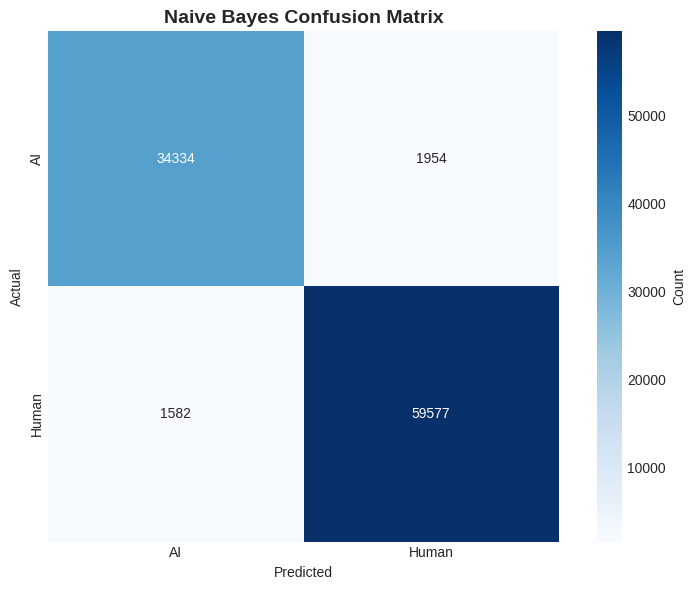


 Top Features for Classification:

Top 10 features for HUMAN class:
  student              log prob: -5.9429
  important            log prob: -6.0380
  help                 log prob: -6.1432
  people               log prob: -6.2005
  life                 log prob: -6.2035
  time                 log prob: -6.3086
  make                 log prob: -6.3100
  lead                 log prob: -6.3231
  benefit              log prob: -6.3419
  conclusion           log prob: -6.3731

Top 10 features for AI class:
  student              log prob: -5.7690
  people               log prob: -5.7959
  car                  log prob: -5.9051
  school               log prob: -5.9590
  like                 log prob: -6.0393
  think                log prob: -6.0478
  time                 log prob: -6.1335
  thing                log prob: -6.1351
  make                 log prob: -6.1828
  help                 log prob: -6.1926

Top 10 most discriminative features:
  writing express      diff: 6.4488 (prefe

In [17]:

print("\nEvaluating Naive Bayes on test set...")
y_test_pred = nb_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\n Test Set Performance:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_test_pred, 
                           target_names=label_encoder.classes_))

print(" Confusion Matrix:")
cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(cm, 
                     index=label_encoder.classes_,
                     columns=label_encoder.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', 
            square=True, cbar_kws={'label': 'Count'})
plt.title('Naive Bayes Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\n Top Features for Classification:")
if hasattr(nb_model, 'feature_log_prob_'):
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    print("\nTop 10 features for HUMAN class:")
    human_log_probs = nb_model.feature_log_prob_[0]
    top_human_idx = np.argsort(human_log_probs)[-10:][::-1]
    for idx in top_human_idx:
        print(f"  {feature_names[idx]:20} log prob: {human_log_probs[idx]:.4f}")
    
    print("\nTop 10 features for AI class:")
    ai_log_probs = nb_model.feature_log_prob_[1]
    top_ai_idx = np.argsort(ai_log_probs)[-10:][::-1]
    for idx in top_ai_idx:
        print(f"  {feature_names[idx]:20} log prob: {ai_log_probs[idx]:.4f}")
    
    print("\nTop 10 most discriminative features:")
    diff_log_probs = np.abs(human_log_probs - ai_log_probs)
    top_diff_idx = np.argsort(diff_log_probs)[-10:][::-1]
    for idx in top_diff_idx:
        human_prob = np.exp(human_log_probs[idx])
        ai_prob = np.exp(ai_log_probs[idx])
        prefers = "Human" if human_prob > ai_prob else "AI"
        print(f"  {feature_names[idx]:20} diff: {diff_log_probs[idx]:.4f} (prefers {prefers})")


Evaluating XGB on test set...

 Test Set Performance:
Accuracy: 0.6920
F1 Score: 0.6816

 Classification Report:
              precision    recall  f1-score   support

          AI       0.61      0.47      0.53     36288
       Human       0.72      0.82      0.77     61159

    accuracy                           0.69     97447
   macro avg       0.67      0.65      0.65     97447
weighted avg       0.68      0.69      0.68     97447

 Confusion Matrix:


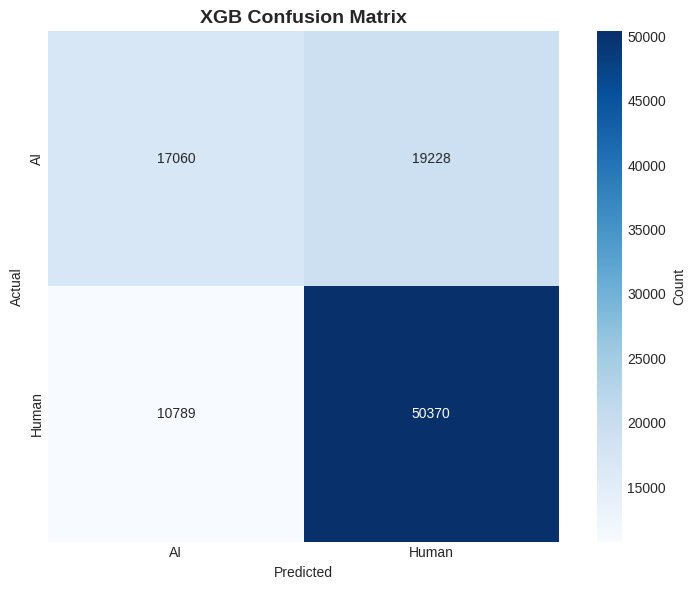


 Top Features for Classification:

Top 10 features for HUMAN class:
  student              log prob: -5.9429
  important            log prob: -6.0380
  help                 log prob: -6.1432
  people               log prob: -6.2005
  life                 log prob: -6.2035
  time                 log prob: -6.3086
  make                 log prob: -6.3100
  lead                 log prob: -6.3231
  benefit              log prob: -6.3419
  conclusion           log prob: -6.3731

Top 10 features for AI class:
  student              log prob: -5.7690
  people               log prob: -5.7959
  car                  log prob: -5.9051
  school               log prob: -5.9590
  like                 log prob: -6.0393
  think                log prob: -6.0478
  time                 log prob: -6.1335
  thing                log prob: -6.1351
  make                 log prob: -6.1828
  help                 log prob: -6.1926

Top 10 most discriminative features:
  writing express      diff: 6.4488 (prefe

In [18]:

print("\nEvaluating XGB on test set...")
y_test_pred = xgb_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\n Test Set Performance:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_test_pred, 
                           target_names=label_encoder.classes_))

print(" Confusion Matrix:")
cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(cm, 
                     index=label_encoder.classes_,
                     columns=label_encoder.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', 
            square=True, cbar_kws={'label': 'Count'})
plt.title('XGB Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\n Top Features for Classification:")
if hasattr(nb_model, 'feature_log_prob_'):
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    print("\nTop 10 features for HUMAN class:")
    human_log_probs = nb_model.feature_log_prob_[0]
    top_human_idx = np.argsort(human_log_probs)[-10:][::-1]
    for idx in top_human_idx:
        print(f"  {feature_names[idx]:20} log prob: {human_log_probs[idx]:.4f}")
    
    print("\nTop 10 features for AI class:")
    ai_log_probs = nb_model.feature_log_prob_[1]
    top_ai_idx = np.argsort(ai_log_probs)[-10:][::-1]
    for idx in top_ai_idx:
        print(f"  {feature_names[idx]:20} log prob: {ai_log_probs[idx]:.4f}")
    
    print("\nTop 10 most discriminative features:")
    diff_log_probs = np.abs(human_log_probs - ai_log_probs)
    top_diff_idx = np.argsort(diff_log_probs)[-10:][::-1]
    for idx in top_diff_idx:
        human_prob = np.exp(human_log_probs[idx])
        ai_prob = np.exp(ai_log_probs[idx])
        prefers = "Human" if human_prob > ai_prob else "AI"
        print(f"  {feature_names[idx]:20} diff: {diff_log_probs[idx]:.4f} (prefers {prefers})")

In [ ]:
nb_model

In [ ]:
with open("nb_model.pkl", "wb") as f:
    pickle.dump(nb_model, f)